In [ ]:
pip install keras==2.12.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 17.1 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 2.15.0
    Uninstalling keras-2.15.0:
      Successfully uninstalled keras-2.15.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.15.0 requires keras<2.16,>=2.15.0, but you have keras 2.12.0 which is incompatible.


In [ ]:
# 2. Mounting google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1.import library
import numpy as np #importing the numpy library which will be used in this project
import pandas as pd #importing the pandas library which will be used in this project
import matplotlib.pyplot as plt
import seaborn as sns#importing the seaborn library which will be used for plotting the heatmaps
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns #importing the seaborn library which will be used for plotting the heatmaps
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split#importing the test_train_split library from sklearn model_selection which will be used in this project
from sklearn.metrics import confusion_matrix, accuracy_score#importing the confusion matrix from sklearn.metrics library which will be used in this project
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, mean_squared_error, classification_report, accuracy_score, log_loss
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
from sklearn.svm import SVC#importing the SVC from sklearn.svm library which will be used in this project
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier#importing the Random Forest Classifier library which will be used in this project
from sklearn.ensemble import GradientBoostingClassifier#importing the Gradient Boosting Classifier library which will be used in this project
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn import linear_model, decomposition, datasets
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:
#Loading the dataset
data= pd.read_csv("drive/MyDrive/Colab Notebooks/@all 2016 Dataset @.csv")

In [ ]:
# first 5 rows of the datase
data.head()

,No,TIN,TN,TP,AST,Tpt,GPDTP,TEDTP,NILDTP,PTDTP,GPRTD,TERTD,NILRTP,PTRTD,Output
0,1,790722,5-BROTHERS GENERAL TRADE & TRANSPORT PLC,2013,DONE BY TAXPAYER & Revised by Tax Department,PLC,8279,1604,6675,2003,8279,1604,6675,2003,0
1,2,790722,5-BROTHERS GENERAL TRADE & TRANSPORT PLC,2014,DONE BY TAXPAYER & Revised by Tax Department,PLC,1134,1396,-262,-79,1135,1396,-261,-78,1
2,3,790722,5-BROTHERS GENERAL TRADE & TRANSPORT PLC,2020,DONE BY TAXPAYER & Revised by Tax Department,PLC,3370,1005,2365,710,3373,1005,2368,710,1
3,4,790722,5-BROTHERS GENERAL TRADE & TRANSPORT PLC,2016,DONE BY TAXPAYER & Revised by Tax Department,PLC,1837,2124,-287,-86,1836,2124,-288,-86,0
4,5,790722,5-BROTHERS GENERAL TRADE & TRANSPORT PLC,2007,DONE BY TAXPAYER & Revised by Tax Department,PLC,3008,4872,-1864,-559,3005,4872,-1867,-560,0


In [ ]:
# number of rows and Columns in this dataset
data.shape

(18630, 15)

In [ ]:
# Dataset informations
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18630 entries, 0 to 18629
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   No      18630 non-null  int64 
 1   TIN     18630 non-null  object
 2   TN      18630 non-null  object
 3   TP      18630 non-null  int64 
 4   AST     18630 non-null  object
 5   Tpt     18630 non-null  object
 6   GPDTP   18630 non-null  int64 
 7   TEDTP   18630 non-null  int64 
 8   NILDTP  18630 non-null  int64 
 9   PTDTP   18630 non-null  int64 
 10  GPRTD   18630 non-null  int64 
 11  TERTD   18630 non-null  int64 
 12  NILRTP  18630 non-null  int64 
 13  PTRTD   18630 non-null  int64 
 14  Output  18630 non-null  int64 
dtypes: int64(11), object(4)
memory usage: 2.1+ MB


In [ ]:
data.isnull().sum() ##checking if there is any missing value in our dataset

No        0
TIN       0
TN        0
TP        0
AST       0
Tpt       0
GPDTP     0
TEDTP     0
NILDTP    0
PTDTP     0
GPRTD     0
TERTD     0
NILRTP    0
PTRTD     0
Output    0
dtype: int64

In [ ]:
data.drop(['No','TIN','TN','TP','AST','Tpt',], axis=1, inplace=True)

In [ ]:
data.head()#printing the first 5 rows of the dataset using head() function

,GPDTP,TEDTP,NILDTP,PTDTP,GPRTD,TERTD,NILRTP,PTRTD,Output
0,8279,1604,6675,2003,8279,1604,6675,2003,0
1,1134,1396,-262,-79,1135,1396,-261,-78,1
2,3370,1005,2365,710,3373,1005,2368,710,1
3,1837,2124,-287,-86,1836,2124,-288,-86,0
4,3008,4872,-1864,-559,3005,4872,-1867,-560,0


In [ ]:
# Distribution  of legit transactions and fraudelent transactions
data['Output'].value_counts()

Output
1    11022
0     7608
Name: count, dtype: int64

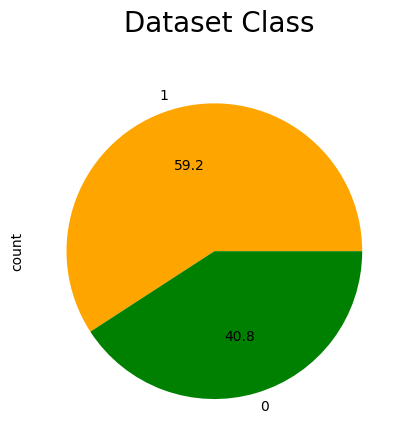

In [ ]:
data['Output'].value_counts().plot.pie(autopct = '%.1f', colors = ['orange', 'green'])
plt.title(" Dataset Class", pad =25, fontdict = {'size' :20})
plt.show()

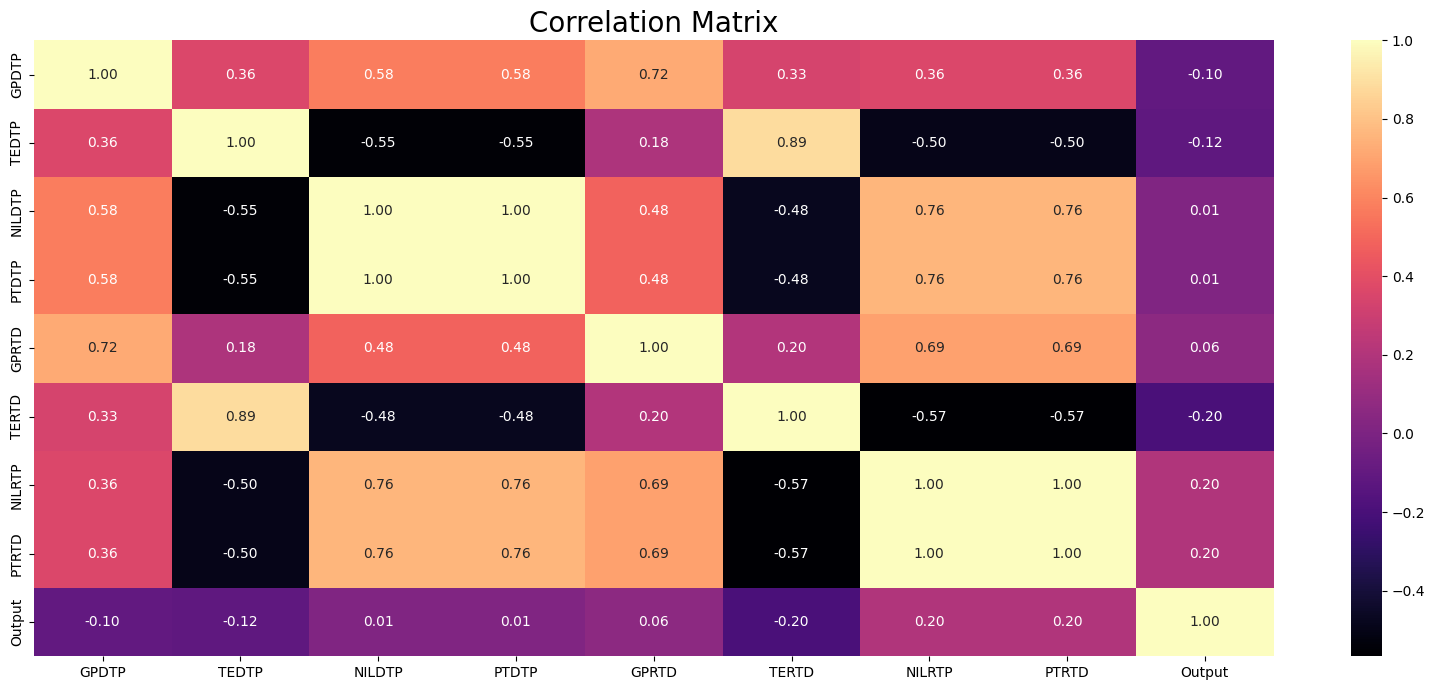

In [ ]:
f, ax = plt.subplots(figsize= [20,8]) #plotting the subplot using the matplot lib functions
sns.heatmap(data.corr(), annot=True, fmt=".2f", ax=ax, cmap = "magma" ) #passing the parameters to our heatmap function like cmap = magma and annot = True
ax.set_title("Correlation Matrix", fontsize=20) #setting the title as Correlation Matrix of the plot
plt.show()#showing the plot

In [ ]:

data= pd.read_csv("drive/MyDrive/Colab Notebooks/2016dataset6@2.csv")

data.drop(['No','TIN','TN','TP','AST','Tpt',], axis=1, inplace=True)

In [ ]:
# Preprocess the data
X = data.drop(columns=["Output"])
y = data["Output"]

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [ ]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
print("Print the value of X:")
print(X)

Print the value of X:
       GPDTP  TEDTP  NILDTP  PTDTP  GPRTD  TERTD  NILRTP  PTRTD
0       8279   1604    6675   2003   8279   1604    6675   2003
1       1134   1396    -262    -79   1135   1396    -261    -78
2       3370   1005    2365    710   3373   1005    2368    710
3       1837   2124    -287    -86   1836   2124    -288    -86
4       3008   4872   -1864   -559   3005   4872   -1867   -560
...      ...    ...     ...    ...    ...    ...     ...    ...
18625      0      0       0      0    786      0     786    236
18626   9087      0    9087   2726   9676   8678     998    299
18627      0      0       0      0    781      0     781    234
18628   6757   7567    -810   -243   7775      0    7775   2333
18629      0      0       0      0      0   8768   -8768  -2630

[18630 rows x 8 columns]


In [ ]:
print("Print the value of y:")
print(y)

Print the value of y:
0        0
1        1
2        1
3        0
4        0
        ..
18625    1
18626    0
18627    1
18628    1
18629    0
Name: Output, Length: 18630, dtype: int64


Develop Machine Learning Algorithms

**1.	Support Vector Machine (SVM) Model**

Confusion Matrix (Training):
[[5177  939]
 [ 957 7831]]
Confusion Matrix (Testing):
[[1258  234]
 [ 271 1963]]


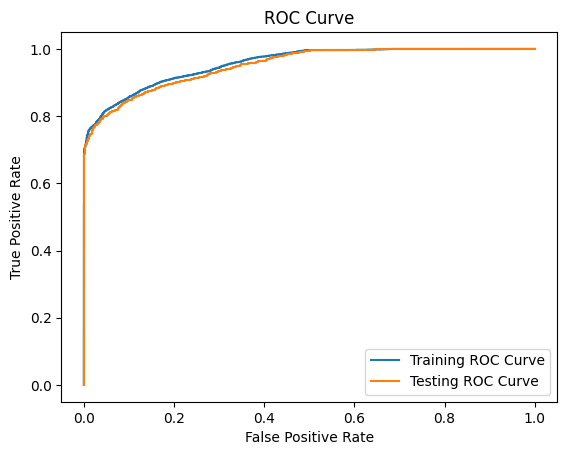

AUC Score (Training): 0.9565981488818958
AUC Score (Testing): 0.9509490784632333
Mean Squared Error (Training): 0.12721417069243157
Mean Squared Error (Testing): 0.13553408480944712
Best Hyperparameter: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Classification Report (Training):
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      6116
           1       0.89      0.89      0.89      8788

    accuracy                           0.87     14904
   macro avg       0.87      0.87      0.87     14904
weighted avg       0.87      0.87      0.87     14904

Classification Report (Testing):
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1492
           1       0.89      0.88      0.89      2234

    accuracy                           0.86      3726
   macro avg       0.86      0.86      0.86      3726
weighted avg       0.87      0.86      0.86      3726

Accuracy Score (Training): 0.87278

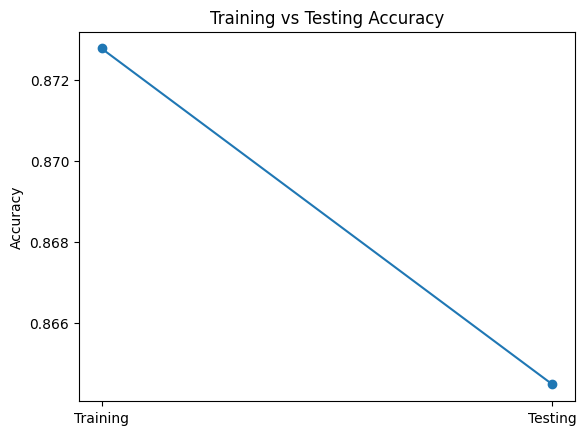

Error Rate (Training): 0.12721417069243157
Error Rate (Testing): 0.13553408480944712
For Support vector machine Model best parameter is: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}


,param_C,param_gamma,param_kernel,mean_test_score,rank_test_score
0,0.1,0.1,linear,0.705583,16
1,0.1,0.1,rbf,0.654253,22
2,0.1,0.1,poly,0.639091,23
3,0.1,0.01,linear,0.705583,16
4,0.1,0.01,rbf,0.631173,25
5,0.1,0.01,poly,0.589640,29
6,0.1,0.001,linear,0.705583,16
7,0.1,0.001,rbf,0.592794,28
8,0.1,0.001,poly,0.589640,29
9,0.1,0.0001,linear,0.705583,16


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, mean_squared_error, classification_report, accuracy_score, log_loss
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Load  dataset
data= pd.read_csv("drive/MyDrive/Colab Notebooks/2016dataset6@2.csv")
data.drop(['No','TIN','TN','TP','AST','Tpt',], axis=1, inplace=True)

# Preprocess the data
X = data.drop(columns=["Output"])
y = data["Output"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize SVM classifier
svm_model = SVC()

# Tune hyperparameters using GridSearchCV
param_grid = {'C': [0.1,10,100 ],'kernel': ['linear', 'rbf', 'poly'], 'gamma': [0.1, 0.01, 0.001, 0.0001]}
grid_search = GridSearchCV(svm_model, param_grid, cv=10, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

# Get best parameters
best_params = grid_search.best_params_

# Initialize SVM classifier with best parameters
svm_model = SVC(C=best_params['C'], gamma=best_params['gamma'])

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = svm_model.predict(X_train_scaled)
y_test_pred = svm_model.predict(X_test_scaled)

# Confusion Matrix
conf_matrix_train = confusion_matrix(y_train, y_train_pred)
conf_matrix_test = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix (Training):")
print(conf_matrix_train)
print("Confusion Matrix (Testing):")
print(conf_matrix_test)

# ROC Curve and AUC Score
y_train_pred_prob = svm_model.decision_function(X_train_scaled)
y_test_pred_prob = svm_model.decision_function(X_test_scaled)
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_prob)
plt.plot(fpr_train, tpr_train, label='Training ROC Curve')
plt.plot(fpr_test, tpr_test, label='Testing ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
auc_score_train = roc_auc_score(y_train, y_train_pred_prob)
auc_score_test = roc_auc_score(y_test, y_test_pred_prob)
print("AUC Score (Training):", auc_score_train)
print("AUC Score (Testing):", auc_score_test)

# MSE Error Rate
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
print("Mean Squared Error (Training):", mse_train)
print("Mean Squared Error (Testing):", mse_test)

# Best Hyperparameter
print("Best Hyperparameter:", best_params)

# Classification Report
class_report_train = classification_report(y_train, y_train_pred)
class_report_test = classification_report(y_test, y_test_pred)
print("Classification Report (Training):")
print(class_report_train)
print("Classification Report (Testing):")
print(class_report_test)

# Classification Accuracy Score
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)
print("Accuracy Score (Training):", accuracy_train)
print("Accuracy Score (Testing):", accuracy_test)

# Logarithmic Loss
log_loss_value_train = log_loss(y_train, y_train_pred_prob)
log_loss_value_test = log_loss(y_test, y_test_pred_prob)
print("Logarithmic Loss (Training):", log_loss_value_train)
print("Logarithmic Loss (Testing):", log_loss_value_test)

# Training vs Test Graph
plt.plot([1, 2], [accuracy_train, accuracy_test], marker='o')
plt.xticks([1, 2], ['Training', 'Testing'])
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy')
plt.show()

# Error rate detection
error_rate_train = np.mean(y_train != y_train_pred)
error_rate_test = np.mean(y_test != y_test_pred)
print("Error Rate (Training):", error_rate_train)
print("Error Rate (Testing):", error_rate_test)

#display parameter
grid_search.cv_results_

# loading the results to pandas dataframe
result1 = pd.DataFrame(grid_search.cv_results_)
result1.head()

best_params = grid_search.best_params_
#best_parameters = best_params.best_params_

print('For Support vector machine Model best parameter is:',best_params)
#grid_search_result1 = result1[['param_C','mean_test_score','rank_test_score']]
grid_search_result1 = result1[['param_C','param_gamma','param_kernel','mean_test_score','rank_test_score']]
grid_search_result1

**2.	Logistic Regression (LR) Model**

Confusion Matrix (Training):
[[5683  359]
 [1363 7499]]
Confusion Matrix (Testing):
[[1479   87]
 [ 338 1822]]


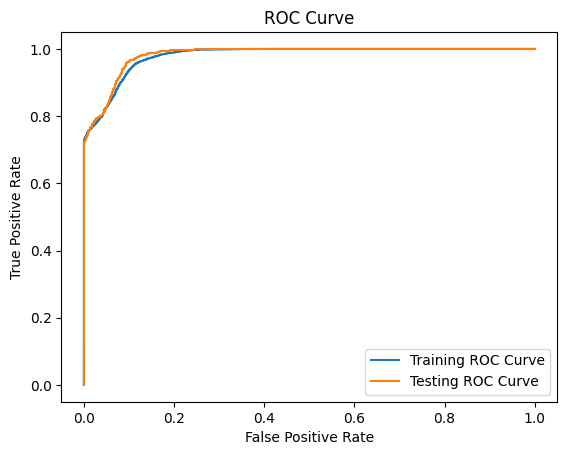

AUC Score (Training): 0.9796142454559601
AUC Score (Testing): 0.9822921101177805
Mean Squared Error (Training): 0.11553945249597423
Mean Squared Error (Testing): 0.11406333870101985
Classification Report (Training):
              precision    recall  f1-score   support

           0       0.81      0.94      0.87      6042
           1       0.95      0.85      0.90      8862

    accuracy                           0.88     14904
   macro avg       0.88      0.89      0.88     14904
weighted avg       0.89      0.88      0.89     14904

Classification Report (Testing):
              precision    recall  f1-score   support

           0       0.81      0.94      0.87      1566
           1       0.95      0.84      0.90      2160

    accuracy                           0.89      3726
   macro avg       0.88      0.89      0.88      3726
weighted avg       0.90      0.89      0.89      3726

Accuracy Score (Training): 0.8844605475040258
Accuracy Score (Testing): 0.8859366612989802
Logari

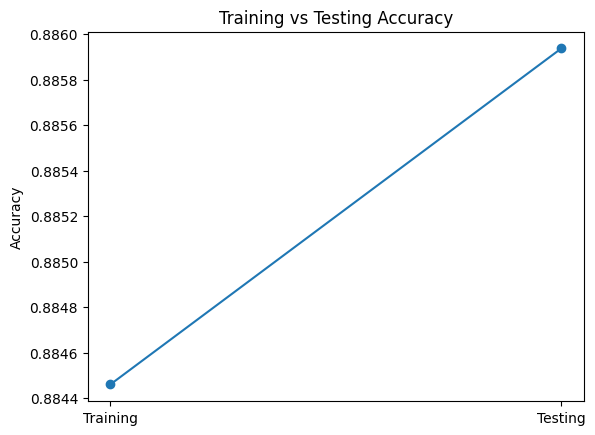

Error Rate (Training): 0.11553945249597423
Error Rate (Testing): 0.11406333870101985


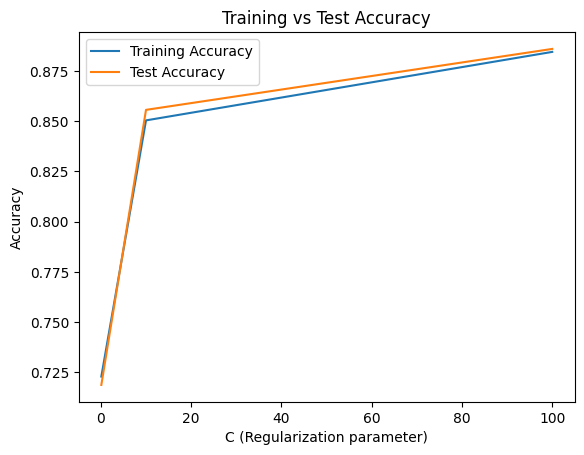

For Logistic regression Model best parameter is: {'C': 100}


,param_C,mean_test_score,rank_test_score
0,0.001,0.641506,6
1,0.01,0.675859,5
2,0.1,0.721282,4
3,1,0.824073,3
4,10,0.849302,2
5,100,0.881710,1


In [ ]:
# Initialize Logistic Regression classifier
log_reg_model = LogisticRegression()

# Tune hyperparameters using GridSearchCV
param_grid = {'C': [0.001,0.01,0.1,1,10, 100]}
grid_search = GridSearchCV(log_reg_model, param_grid, cv=10, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

# Get best parameters
best_params = grid_search.best_params_

# Initialize Logistic Regression classifier with best parameters
log_reg_model = LogisticRegression(C=best_params['C'])

# Train the model
log_reg_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = log_reg_model.predict(X_train_scaled)
y_test_pred = log_reg_model.predict(X_test_scaled)

# Confusion Matrix
conf_matrix_train = confusion_matrix(y_train, y_train_pred)
conf_matrix_test = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix (Training):")
print(conf_matrix_train)
print("Confusion Matrix (Testing):")
print(conf_matrix_test)

# ROC Curve and AUC Score
y_train_pred_prob = log_reg_model.predict_proba(X_train_scaled)[:, 1]
y_test_pred_prob = log_reg_model.predict_proba(X_test_scaled)[:, 1]
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_prob)
plt.plot(fpr_train, tpr_train, label='Training ROC Curve')
plt.plot(fpr_test, tpr_test, label='Testing ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
auc_score_train = roc_auc_score(y_train, y_train_pred_prob)
auc_score_test = roc_auc_score(y_test, y_test_pred_prob)
print("AUC Score (Training):", auc_score_train)
print("AUC Score (Testing):", auc_score_test)

# MSE Error Rate
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
print("Mean Squared Error (Training):", mse_train)
print("Mean Squared Error (Testing):", mse_test)

# Best Hyperparameter
#print("Best Hyperparameter:", best_params)

# Classification Report
class_report_train = classification_report(y_train, y_train_pred)
class_report_test = classification_report(y_test, y_test_pred)
print("Classification Report (Training):")
print(class_report_train)
print("Classification Report (Testing):")
print(class_report_test)

# Classification Accuracy Score
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)
print("Accuracy Score (Training):", accuracy_train)
print("Accuracy Score (Testing):", accuracy_test)

# Logarithmic Loss
log_loss_value_train = log_loss(y_train, y_train_pred_prob)
log_loss_value_test = log_loss(y_test, y_test_pred_prob)
print("Logarithmic Loss (Training):", log_loss_value_train)
print("Logarithmic Loss (Testing):", log_loss_value_test)

# Training vs Test Graph
plt.plot([1, 2], [accuracy_train, accuracy_test], marker='o')
plt.xticks([1, 2], ['Training', 'Testing'])
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy')
plt.show()

# Error rate detection
error_rate_train = np.mean(y_train != y_train_pred)
error_rate_test = np.mean(y_test != y_test_pred)
print("Error Rate (Training):", error_rate_train)
print("Error Rate (Testing):", error_rate_test)


# Training vs Test Graph
C_values = [0.1, 10, 100]
train_accuracies = []
test_accuracies = []
for C in C_values:
    model = LogisticRegression(C=C)
    model.fit(X_train_scaled, y_train)
    train_accuracies.append(accuracy_score(y_train, model.predict(X_train_scaled)))
    test_accuracies.append(accuracy_score(y_test, model.predict(X_test_scaled)))

plt.plot(C_values, train_accuracies, label='Training Accuracy')
plt.plot(C_values, test_accuracies, label='Test Accuracy')
plt.xlabel('C (Regularization parameter)')
plt.ylabel('Accuracy')
plt.title('Training vs Test Accuracy')
plt.legend()
plt.show()

#display parameter
grid_search.cv_results_

# loading the results to pandas dataframe
result1 = pd.DataFrame(grid_search.cv_results_)
result1.head()

best_params = grid_search.best_params_
#best_parameters = best_params.best_params_

print('For Logistic regression Model best parameter is:',best_params)
grid_search_result1 = result1[['param_C','mean_test_score','rank_test_score']]
grid_search_result1

**3.	 Random Forest (RF) Model**

Confusion Matrix (Training):
[[6116    0]
 [   0 8788]]
Confusion Matrix (Testing):
[[1076  416]
 [ 329 1905]]


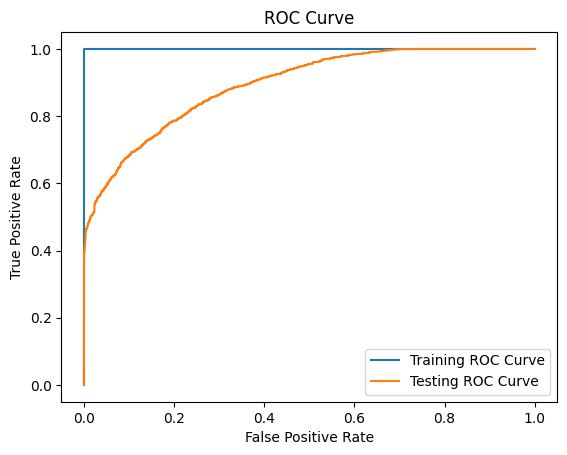

AUC Score (Training): 1.0
AUC Score (Testing): 0.8931805199200271
Mean Squared Error (Training): 0.0
Mean Squared Error (Testing): 0.19994632313472893
Best Hyperparameters: {'max_depth': 30, 'n_estimators': 200}
Classification Report (Training):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6116
           1       1.00      1.00      1.00      8788

    accuracy                           1.00     14904
   macro avg       1.00      1.00      1.00     14904
weighted avg       1.00      1.00      1.00     14904

Classification Report (Testing):
              precision    recall  f1-score   support

           0       0.77      0.72      0.74      1492
           1       0.82      0.85      0.84      2234

    accuracy                           0.80      3726
   macro avg       0.79      0.79      0.79      3726
weighted avg       0.80      0.80      0.80      3726

Accuracy Score (Training): 1.0
Accuracy Score (Testing): 0.80005367

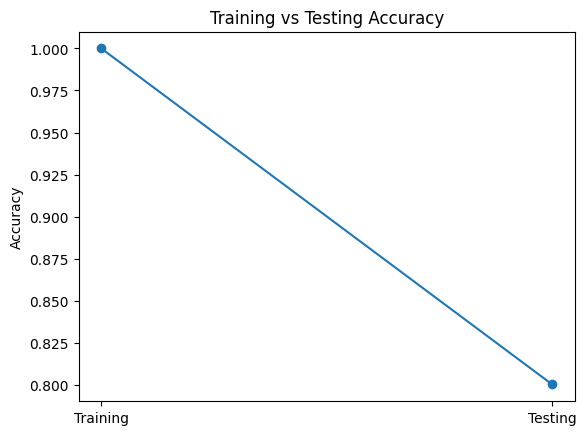

Error Rate (Training): 0.0
Error Rate (Testing): 0.19994632313472893
The best parameter of Random forest Model is: {'max_depth': 30, 'n_estimators': 200}


,param_max_depth,param_n_estimators,mean_test_score,rank_test_score
0,None,50,0.788647,18
1,None,100,0.788110,20
2,None,150,0.790660,8
3,None,200,0.789116,16
4,None,250,0.789318,10
5,10,50,0.766305,25
6,10,100,0.768787,21
7,10,150,0.767982,22
8,10,200,0.767580,24
9,10,250,0.767714,23


In [ ]:
# Initialize Random Forest classifier
rf_model = RandomForestClassifier()

# Tune hyperparameters using GridSearchCV
param_grid = {'n_estimators': [50, 100, 150,200,250], 'max_depth': [None, 10, 20,30,40]}
grid_search = GridSearchCV(rf_model, param_grid, cv=10, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get best parameters
best_params = grid_search.best_params_

# Initialize Random Forest classifier with best parameters
rf_model = RandomForestClassifier(n_estimators=best_params['n_estimators'], max_depth=best_params['max_depth'])

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Confusion Matrix
conf_matrix_train = confusion_matrix(y_train, y_train_pred)
conf_matrix_test = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix (Training):")
print(conf_matrix_train)
print("Confusion Matrix (Testing):")
print(conf_matrix_test)

# ROC Curve and AUC Score
y_train_pred_prob = rf_model.predict_proba(X_train)[:, 1]
y_test_pred_prob = rf_model.predict_proba(X_test)[:, 1]
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_prob)
plt.plot(fpr_train, tpr_train, label='Training ROC Curve')
plt.plot(fpr_test, tpr_test, label='Testing ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
auc_score_train = roc_auc_score(y_train, y_train_pred_prob)
auc_score_test = roc_auc_score(y_test, y_test_pred_prob)
print("AUC Score (Training):", auc_score_train)
print("AUC Score (Testing):", auc_score_test)

# MSE Error Rate
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
print("Mean Squared Error (Training):", mse_train)
print("Mean Squared Error (Testing):", mse_test)

# Best Hyperparameters
print("Best Hyperparameters:", best_params)

# Classification Report
class_report_train = classification_report(y_train, y_train_pred)
class_report_test = classification_report(y_test, y_test_pred)
print("Classification Report (Training):")
print(class_report_train)
print("Classification Report (Testing):")
print(class_report_test)

# Classification Accuracy Score
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)
print("Accuracy Score (Training):", accuracy_train)
print("Accuracy Score (Testing):", accuracy_test)

# Logarithmic Loss
log_loss_value_train = log_loss(y_train, y_train_pred_prob)
log_loss_value_test = log_loss(y_test, y_test_pred_prob)
print("Logarithmic Loss (Training):", log_loss_value_train)
print("Logarithmic Loss (Testing):", log_loss_value_test)

# Training vs Test Graph
plt.plot([1, 2], [accuracy_train, accuracy_test], marker='o')
plt.xticks([1, 2], ['Training', 'Testing'])
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy')
plt.show()

# Error rate detection
error_rate_train = np.mean(y_train != y_train_pred)
error_rate_test = np.mean(y_test != y_test_pred)
print("Error Rate (Training):", error_rate_train)
print("Error Rate (Testing):", error_rate_test)

#display parameter
grid_search.cv_results_

# loading the results to pandas dataframe
result5 = pd.DataFrame(grid_search.cv_results_)
result5.head()

best_params = grid_search.best_estimator_
best_parameters = grid_search.best_params_

######best_params = best_dnn_classifier.best_params_
#######best_parameters = best_params.best_params_

print('The best parameter of Random forest Model is:',best_parameters)
#grid_search_result5 = result5[['params','mean_test_score','rank_test_score']]
grid_search_result5 = result5[['param_max_depth','param_n_estimators','mean_test_score','rank_test_score']]
grid_search_result5


**4.	 K-Nearest Neighbors (KNN) Model**

In [ ]:
# 1.import library
import numpy as np #importing the numpy library which will be used in this project
import pandas as pd #importing the pandas library which will be used in this project
import matplotlib.pyplot as plt
import seaborn as sns#importing the seaborn library which will be used for plotting the heatmaps
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns #importing the seaborn library which will be used for plotting the heatmaps
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split#importing the test_train_split library from sklearn model_selection which will be used in this project
from sklearn.metrics import confusion_matrix, accuracy_score#importing the confusion matrix from sklearn.metrics library which will be used in this project
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, mean_squared_error, classification_report, accuracy_score, log_loss
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
from sklearn.svm import SVC#importing the SVC from sklearn.svm library which will be used in this project
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier#importing the Random Forest Classifier library which will be used in this project
from sklearn.ensemble import GradientBoostingClassifier#importing the Gradient Boosting Classifier library which will be used in this project
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn import linear_model, decomposition, datasets
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

Confusion Matrix for Training Set:
[[6116    0]
 [   0 8788]]

Classification Report for Training Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6116
           1       1.00      1.00      1.00      8788

    accuracy                           1.00     14904
   macro avg       1.00      1.00      1.00     14904
weighted avg       1.00      1.00      1.00     14904


Confusion Matrix for Testing Set:
[[ 997  495]
 [ 466 1768]]

Classification Report for Testing Set:
              precision    recall  f1-score   support

           0       0.68      0.67      0.67      1492
           1       0.78      0.79      0.79      2234

    accuracy                           0.74      3726
   macro avg       0.73      0.73      0.73      3726
weighted avg       0.74      0.74      0.74      3726



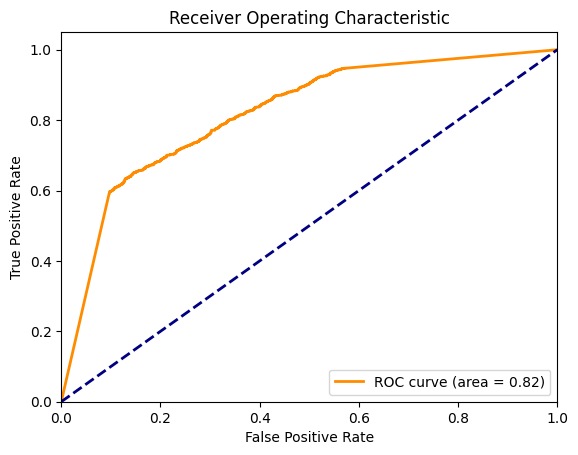

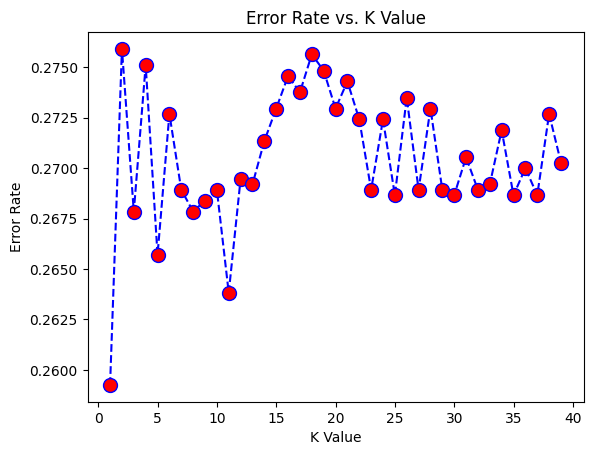

The best parameter of KNN Model is: {'n_neighbors': 3, 'weights': 'distance'}


,param_weights,param_n_neighbors,mean_test_score,rank_test_score
0,uniform,1,0.740539,3
1,distance,1,0.740539,3
2,uniform,3,0.733695,13
3,distance,3,0.742015,1
4,uniform,5,0.727053,17
5,distance,5,0.740069,6
6,uniform,7,0.726852,18
7,distance,7,0.739667,9
8,uniform,9,0.725308,22
9,distance,9,0.739801,8


In [ ]:
# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc



# Step 3: Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Define hyperparameter list and perform hyperparameter tuning
param_grid = {'n_neighbors': [1,3,5,7,9,11,13,15,17,19,21], 'weights': ['uniform', 'distance']}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(X_train, y_train)




# Step 5: Get the best hyperparameters
best_params = grid_search.best_params_
best_knn = grid_search.best_estimator_



# Step 6: Evaluate the model
# Confusion Matrix and Classification Report for Training Set
y_train_pred = best_knn.predict(X_train)
print("Confusion Matrix for Training Set:")
print(confusion_matrix(y_train, y_train_pred))
print("\nClassification Report for Training Set:")
print(classification_report(y_train, y_train_pred))

# Confusion Matrix and Classification Report for Testing Set
y_test_pred = best_knn.predict(X_test)
print("\nConfusion Matrix for Testing Set:")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report for Testing Set:")
print(classification_report(y_test, y_test_pred))

# Step 7: Plot ROC Curve
y_test_prob = best_knn.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Step 8: Plot Error Rate Graph (Optional)
error_rate = []
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure()
plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.show()


#display parameter
grid_search.cv_results_

# loading the results to pandas dataframe
result5 = pd.DataFrame(grid_search.cv_results_)
result5.head()

best_params = grid_search.best_estimator_
best_parameters = grid_search.best_params_


print('The best parameter of KNN Model is:',best_parameters)
grid_search_result5 = result5[['param_weights','param_n_neighbors','mean_test_score','rank_test_score']]
grid_search_result5

#2nd KNN Code

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load  dataset
data= pd.read_csv("drive/MyDrive/Colab Notebooks/2016dataset6@2.csv")
data.drop(['No','TIN','TN','TP','AST','Tpt',], axis=1, inplace=True)

# Preprocess the data
X = data.drop(columns=["Output"])
y = data["Output"]


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid for grid search
param_grid = {'n_neighbors': range(1, 21)}

# Initialize KNN model
knn_model = KNeighborsClassifier()

# Perform grid search for hyperparameter tuning
grid_search = GridSearchCV(knn_model, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Get best hyperparameters
best_params = grid_search.best_params_

# Train KNN model with best hyperparameters
best_knn_model = KNeighborsClassifier(**best_params)
best_knn_model.fit(X_train, y_train)

# Predictions
y_pred_train = best_knn_model.predict(X_train)
y_pred_test = best_knn_model.predict(X_test)

# Model evaluation
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)
conf_matrix = confusion_matrix(y_test, y_pred_test)
class_report = classification_report(y_test, y_pred_test)

# Plotting training vs test accuracy graph
plt.figure(figsize=(10, 5))
plt.plot(['Training', 'Testing'], [accuracy_train, accuracy_test], marker='o')
plt.title('Training vs Testing Accuracy')
plt.xlabel('Dataset')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

# Plotting confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
classes = ['Non_Evasion(0)', 'Evasion(1)']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, str(conf_matrix[i][j]), horizontalalignment='center', color='white' if conf_matrix[i][j] > (conf_matrix.max() / 2) else 'black')

plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.tight_layout()

# Plotting classification report
print("Classification Report:")
print(class_report)

# Plotting error rate detection graph
plt.figure(figsize=(10, 5))
#plt.bar(['Training', 'Testing'], [1-accuracy_train, 1-accuracy_test], color=['blue', 'orange'])
#plt.title('Error Rate Detection')
plt.xlabel('Dataset')
#plt.ylabel('Error Rate')
plt.show()


Confusion Matrix for Training Set:
[[6116    0]
 [   0 8788]]

Classification Report for Training Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6116
           1       1.00      1.00      1.00      8788

    accuracy                           1.00     14904
   macro avg       1.00      1.00      1.00     14904
weighted avg       1.00      1.00      1.00     14904


Confusion Matrix for Testing Set:
[[ 997  495]
 [ 466 1768]]

Classification Report for Testing Set:
              precision    recall  f1-score   support

           0       0.68      0.67      0.67      1492
           1       0.78      0.79      0.79      2234

    accuracy                           0.74      3726
   macro avg       0.73      0.73      0.73      3726
weighted avg       0.74      0.74      0.74      3726



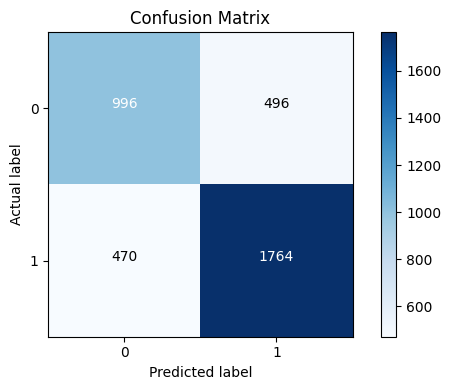

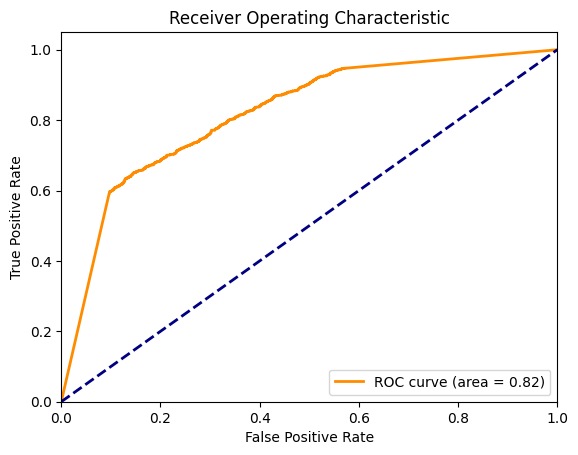

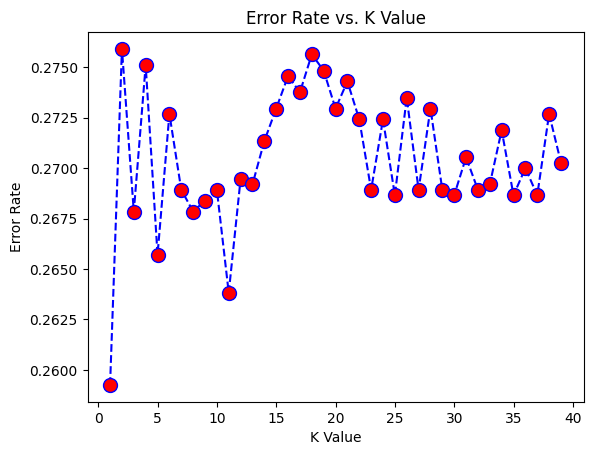

The best parameter of KNN Model is: {'n_neighbors': 3, 'weights': 'distance'}


,param_weights,param_n_neighbors,mean_test_score,rank_test_score
0,uniform,1,0.740539,3
1,distance,1,0.740539,3
2,uniform,3,0.733695,13
3,distance,3,0.742015,1
4,uniform,5,0.727053,17
5,distance,5,0.740069,6
6,uniform,7,0.726852,18
7,distance,7,0.739667,9
8,uniform,9,0.725308,22
9,distance,9,0.739801,8


In [ ]:
# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc



# Step 3: Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid for grid search
param_grid = {'n_neighbors': range(1, 21)}

# Initialize KNN model
knn_model = KNeighborsClassifier()


# Step 4: Define hyperparameter list and perform hyperparameter tuning
param_grid = {'n_neighbors': [1,3, 5, 7, 9, 11,13,15,17,19,21], 'weights': ['uniform', 'distance']}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(X_train, y_train)




# Step 5: Get the best hyperparameters
best_params = grid_search.best_params_
best_knn = grid_search.best_estimator_



# Step 6: Evaluate the model
# Confusion Matrix and Classification Report for Training Set
y_train_pred = best_knn.predict(X_train)
print("Confusion Matrix for Training Set:")
print(confusion_matrix(y_train, y_train_pred))
print("\nClassification Report for Training Set:")
print(classification_report(y_train, y_train_pred))

# Confusion Matrix and Classification Report for Testing Set
y_test_pred = best_knn.predict(X_test)
print("\nConfusion Matrix for Testing Set:")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report for Testing Set:")
print(classification_report(y_test, y_test_pred))


# Plotting confusion matrix
plt.figure(figsize=(6, 4))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
classes = ['0', '1']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, str(conf_matrix[i][j]), horizontalalignment='center', color='white' if conf_matrix[i][j] > (conf_matrix.max() / 2) else 'black')

plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.tight_layout()



# Step 7: Plot ROC Curve
y_test_prob = best_knn.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Step 8: Plot Error Rate Graph (Optional)
error_rate = []
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure()
plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.show()


#display parameter
grid_search.cv_results_

# loading the results to pandas dataframe
result5 = pd.DataFrame(grid_search.cv_results_)
result5.head()

best_params = grid_search.best_estimator_
best_parameters = grid_search.best_params_


print('The best parameter of KNN Model is:',best_parameters)
grid_search_result5 = result5[['param_weights','param_n_neighbors','mean_test_score','rank_test_score']]
grid_search_result5

**5.	Deep Neural Network ( DNN) Model** (2h 26m)

In [ ]:
# Load dataset
#data = pd.read_csv("your_dataset.csv")
#Loading the dataset
data= pd.read_csv("drive/MyDrive/Colab Notebooks/@all 2016 Dataset@.csv")
data.drop(['No','TIN','TN','TP','AST','Tpt',], axis=1, inplace=True)

# Preprocess the data
X = data.drop(columns=["Output"])
y = data["Output"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                288       
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 321
Trainable params: 321
Non-trainable params: 0
_________________________________________________________________
Epoch 1/20
233/233 [==============================] - 1s 2ms/step - loss: 0.6332 - accuracy: 0.6216
Epoch 2/20
233/233 [==============================] - 1s 2ms/step - loss: 0.5710 - accuracy: 0.6675
Epoch 3/20
233/233 [==============================] - 0s 2ms/step - loss: 0.5283 - accuracy: 0.7042
Epoch 4/20
233/233 [==============================] - 1s 2ms/step - loss: 0.4950 - accuracy: 0.7307
Epoch 5/20
233/233 [==============================] - 

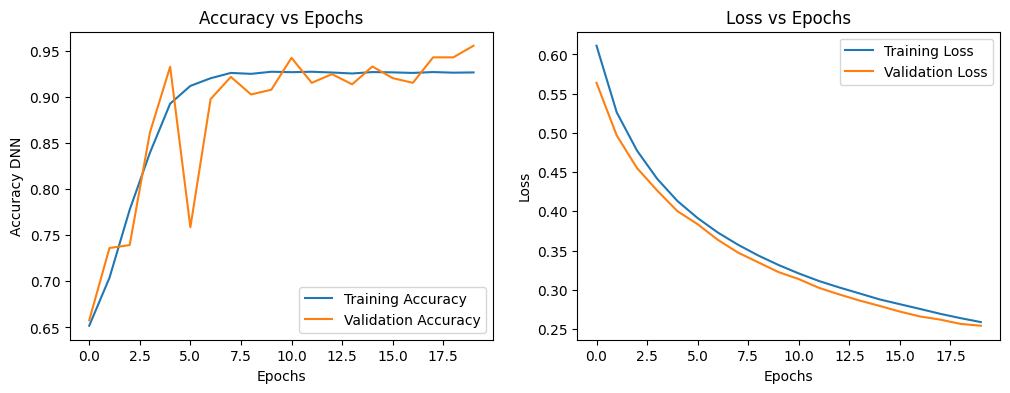

Best Hyperparameters: {'activation': 'relu', 'batch_size': 64, 'epochs': 20, 'hidden_layers': 2, 'learning_rate': 0.01, 'units': 32}
Accuracy: 0.96
Mean Squared Error: 0.08
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1584
           1       0.98      0.94      0.96      2142

    accuracy                           0.96      3726
   macro avg       0.95      0.96      0.96      3726
weighted avg       0.96      0.96      0.96      3726

the best parameter of DNN Model is: {'activation': 'relu', 'batch_size': 64, 'epochs': 20, 'hidden_layers': 2, 'learning_rate': 0.01, 'units': 32}


,param_epochs,param_hidden_layers,param_learning_rate,param_units,param_activation,param_batch_size,mean_test_score,rank_test_score
0,10,1,0.01,32,relu,32,0.940284,24
1,10,1,0.01,64,relu,32,0.909018,95
2,10,1,0.1,32,relu,32,0.945048,13
3,10,1,0.1,64,relu,32,0.922303,67
4,10,1,1,32,relu,32,0.937064,36
...,...,...,...,...,...,...,...,...
123,20,2,0.1,64,tanh,64,0.896873,99
124,20,2,1,32,tanh,64,0.944847,14
125,20,2,1,64,tanh,64,0.924047,64
126,20,2,10,32,tanh,64,0.944780,15


In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import GridSearchCV

# Load  dataset
data= pd.read_csv("drive/MyDrive/Colab Notebooks/@all 2016 Dataset@.csv")
data.drop(['No','TIN','TN','TP','AST','Tpt',], axis=1, inplace=True)


# Assuming your dataset has features (X) and labels (y)
X = data.drop('Output', axis=1)  # Adjust 'label_column' to your actual label column
y = data['Output']




# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Function to create a DNN model
def create_model(epochs=10,hidden_layers=1,learning_rate=0.1,units=32, activation='relu',batch_size=32):
    model = Sequential()
    model.add(Dense(units, input_dim=X_train.shape[1], activation=activation))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', metrics=['accuracy'])
    model.summary()
    return model


# Create a KerasClassifier
dnn_classifier = KerasClassifier(build_fn=create_model, epochs=10, verbose=1)


# Define hyperparameters to tune
param_grid = {

     'epochs': [10,20],
    'hidden_layers': [1,2],
    'learning_rate': [0.01,0.1,1,10],
    'units':[32,64,],
    'activation': ['relu', 'tanh'],
    'batch_size': [32,64]
       #'dropout_rate': [0.1,0.15,0.2,0.25,0.3],

}



# Use GridSearchCV for parameter tuning
grid_search = GridSearchCV(dnn_classifier, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_result=grid_search.fit(X_train_scaled, y_train)

# Get the best parameters
best_params = grid_search_result.best_params_

# Train the model with the best parameters
best_dnn_classifier = create_model(**best_params)
history = best_dnn_classifier.fit(X_train_scaled, y_train, epochs=20, verbose=1, validation_data=(X_test_scaled, y_test))

# Make predictions on the test set
y_pred_proba = best_dnn_classifier.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int)

# Evaluate the model
accuracyDNN = accuracy_score(y_test, y_pred)
classification_report_output = classification_report(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred_proba)

# Plot accuracy and loss over epochs
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy DNN')
plt.title('Accuracy vs Epochs')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

plt.show()

# Print results
print(f"Best Hyperparameters: {best_params}")
print(f"Accuracy: {accuracyDNN:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print("Classification Report:")
print(classification_report_output)

#display parameter
grid_search.cv_results_


# loading the results to pandas dataframe
result3 = pd.DataFrame(grid_search.cv_results_)
result3.head()
##########

best_params = grid_search.best_estimator_
best_parameters = grid_search.best_params_



##############3
print('the best parameter of DNN Model is:',best_parameters)
grid_search_result1 = result3[['param_epochs','param_hidden_layers','param_learning_rate','param_units','param_activation','param_batch_size','mean_test_score','rank_test_score']]
grid_search_result1

########### 2nd DNN Code

2DNN

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               1152      
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 1,281
Trainable params: 1,281
Non-trainable params: 0
_________________________________________________________________
Epoch 1/20
466/466 [==============================] - 1s 2ms/step - loss: 0.5587 - accuracy: 0.6830
Epoch 2/20
466/466 [==============================] - 1s 2ms/step - loss: 0.4448 - accuracy: 0.8212
Epoch 3/20
466/466 [==============================] - 1s 2ms/step - loss: 0.3851 - accuracy: 0.8892
Epoch 4/20
466/466 [==============================] - 1s 2ms/step - loss: 0.3450 - accuracy: 0.9083
Epoch 5/20
466/466 [==============================

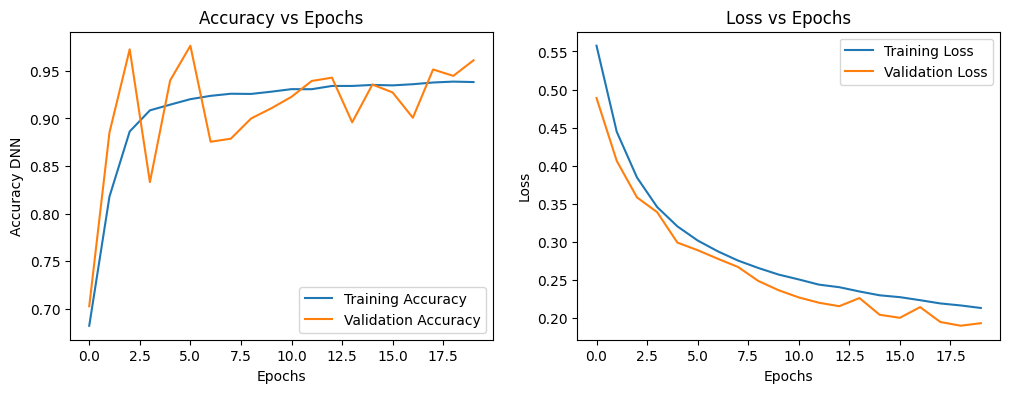

Best Hyperparameters: {'activation': 'tanh', 'batch_size': 32, 'epochs': 20, 'hidden_layers': 4, 'learning_rate': 10, 'units': 128}
Accuracy: 0.96
Mean Squared Error: 0.06
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      1584
           1       0.99      0.94      0.97      2142

    accuracy                           0.96      3726
   macro avg       0.96      0.96      0.96      3726
weighted avg       0.96      0.96      0.96      3726

the best parameter of DNN Model is: {'activation': 'tanh', 'batch_size': 32, 'epochs': 20, 'hidden_layers': 4, 'learning_rate': 10, 'units': 128}


,param_epochs,param_hidden_layers,param_learning_rate,param_units,param_activation,param_batch_size,mean_test_score,rank_test_score
0,10,1,0.1,32,relu,32,0.953905,49
1,10,1,0.1,64,relu,32,0.872115,744
2,10,1,0.1,128,relu,32,0.919082,526
3,10,1,1,32,relu,32,0.895531,681
4,10,1,1,64,relu,32,0.920223,509
...,...,...,...,...,...,...,...,...
1291,30,4,10,64,Sigmoid,128,NaN,865
1292,30,4,10,128,Sigmoid,128,NaN,865
1293,30,4,100,32,Sigmoid,128,NaN,865
1294,30,4,100,64,Sigmoid,128,NaN,865


In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import GridSearchCV

# Load  dataset
data= pd.read_csv("drive/MyDrive/Colab Notebooks/@all 2016 Dataset@.csv")
data.drop(['No','TIN','TN','TP','AST','Tpt',], axis=1, inplace=True)


# Assuming your dataset has features (X) and labels (y)
X = data.drop('Output', axis=1)  # Adjust 'label_column' to your actual label column
y = data['Output']


# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# Function to create a DNN model
def create_model(epochs=10,hidden_layers=1,learning_rate=0.1,units=32, activation='relu',batch_size=32):
    model = Sequential()
    model.add(Dense(units, input_dim=X_train.shape[1], activation=activation))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', metrics=['accuracy'])
    model.summary()
    return model


# Create a KerasClassifier
dnn_classifier = KerasClassifier(build_fn=create_model, epochs=10, verbose=1)


# Define hyperparameters to tune
param_grid = {

     'epochs': [10,20,30],
    'hidden_layers': [1,2,3,4],
    'learning_rate': [0.1,1,10,100],
    'units':[32,64,128],
    'activation': ['relu', 'tanh','Sigmoid'],
    'batch_size': [32,64,128]
       #'dropout_rate': [0.1,0.15,0.2,0.25,0.3],

}
###################


# Use GridSearchCV for parameter tuning
grid_search = GridSearchCV(dnn_classifier, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_result=grid_search.fit(X_train_scaled, y_train)

# Get the best parameters
best_params = grid_search_result.best_params_

# Train the model with the best parameters
best_dnn_classifier = create_model(**best_params)
history = best_dnn_classifier.fit(X_train_scaled, y_train, epochs=20, verbose=1, validation_data=(X_test_scaled, y_test))

# Make predictions on the test set
y_pred_proba = best_dnn_classifier.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int)

# Evaluate the model
accuracyDNN = accuracy_score(y_test, y_pred)
classification_report_output = classification_report(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred_proba)

# Plot accuracy and loss over epochs
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy DNN')
plt.title('Accuracy vs Epochs')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

plt.show()

# Print results
print(f"Best Hyperparameters: {best_params}")
print(f"Accuracy: {accuracyDNN:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print("Classification Report:")
print(classification_report_output)

#display parameter
grid_search.cv_results_

# loading the results to pandas dataframe
#result5 = pd.DataFrame(grid_search.cv_results_)
#result5.head()

#############
# loading the results to pandas dataframe
result3 = pd.DataFrame(grid_search.cv_results_)
result3.head()
##########

best_params = grid_search.best_estimator_
best_parameters = grid_search.best_params_



##############3
print('the best parameter of DNN Model is:',best_parameters)
grid_search_result1 = result3[['param_epochs','param_hidden_layers','param_learning_rate','param_units','param_activation','param_batch_size','mean_test_score','rank_test_score']]
grid_search_result1

##**### 2ns DNN Code**

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                576       
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 641
Trainable params: 641
Non-trainable params: 0
_________________________________________________________________
Epoch 1/30
233/233 [==============================] - 1s 3ms/step - loss: 0.6068 - accuracy: 0.6395
Epoch 2/30
233/233 [==============================] - 1s 3ms/step - loss: 0.5276 - accuracy: 0.6981
Epoch 3/30
233/233 [==============================] - 1s 2ms/step - loss: 0.4734 - accuracy: 0.7742
Epoch 4/30
233/233 [==============================] - 0s 2ms/step - loss: 0.4333 - accuracy: 0.8374
Epoch 5/30
233/233 [==============================] - 

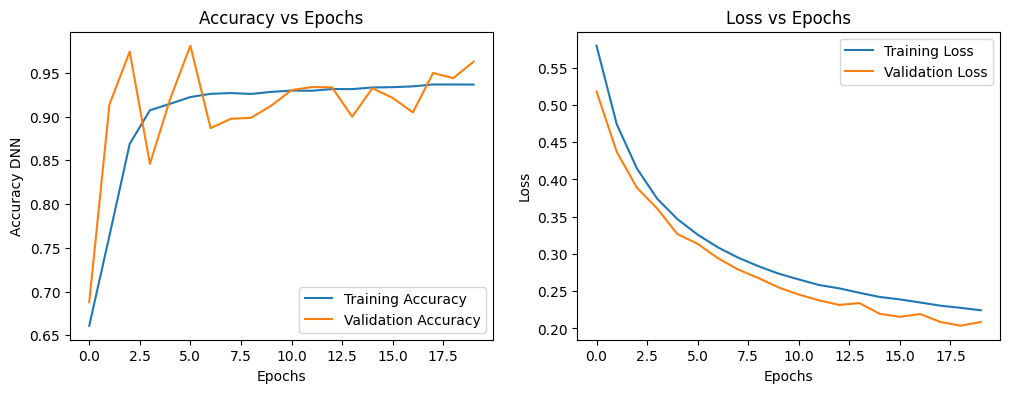

Best Hyperparameters: {'activation': 'tanh', 'batch_size': 64, 'epochs': 30, 'hidden_layers': 3, 'learning_rate': 0.1, 'units': 64}
Accuracy: 0.96
Mean Squared Error: 0.06
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      1584
           1       0.99      0.94      0.97      2142

    accuracy                           0.96      3726
   macro avg       0.96      0.97      0.96      3726
weighted avg       0.96      0.96      0.96      3726

the best parameter of DNN Model is: {'activation': 'tanh', 'batch_size': 64, 'epochs': 30, 'hidden_layers': 3, 'learning_rate': 0.1, 'units': 64}


,param_epochs,param_hidden_layers,param_learning_rate,param_units,param_activation,param_batch_size,mean_test_score,rank_test_score
0,10,1,0.1,32,relu,32,0.933105,103
1,10,1,0.1,64,relu,32,0.948001,23
2,10,1,1,32,relu,32,0.928610,137
3,10,1,1,64,relu,32,0.938674,71
4,10,1,10,32,relu,32,0.934716,94
...,...,...,...,...,...,...,...,...
283,30,3,1,64,tanh,64,0.929817,127
284,30,3,10,32,tanh,64,0.927670,146
285,30,3,10,64,tanh,64,0.937064,80
286,30,3,100,32,tanh,64,0.928811,136


In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import GridSearchCV

# Load  dataset
data= pd.read_csv("drive/MyDrive/Colab Notebooks/@all 2016 Dataset@.csv")
data.drop(['No','TIN','TN','TP','AST','Tpt',], axis=1, inplace=True)


# Assuming your dataset has features (X) and labels (y)
X = data.drop('Output', axis=1)  # Adjust 'label_column' to your actual label column
y = data['Output']


# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to create a DNN model
def create_model(epochs=10,hidden_layers=1,learning_rate=0.1,units=32, activation='relu',batch_size=32):
    model = Sequential()
    model.add(Dense(units, input_dim=X_train.shape[1], activation=activation))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', metrics=['accuracy'])
    model.summary()
    return model


# Create a KerasClassifier
dnn_classifier = KerasClassifier(build_fn=create_model, epochs=10, verbose=1)


# Define hyperparameters to tune
param_grid = {
    'epochs': [10,20,30],
    'hidden_layers': [1,2,3],
    'learning_rate': [0.1,1,10,100],
    'units':[32,64],
    'activation': ['relu','tanh'],
    'batch_size': [32,64]
       #'dropout_rate': [0.1,0.15,0.2,0.25,0.3],

}



# Use GridSearchCV for parameter tuning
grid_search = GridSearchCV(dnn_classifier, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_result=grid_search.fit(X_train_scaled, y_train)

# Get the best parameters
best_params = grid_search_result.best_params_

# Train the model with the best parameters
best_dnn_classifier = create_model(**best_params)
history = best_dnn_classifier.fit(X_train_scaled, y_train, epochs=20, verbose=1, validation_data=(X_test_scaled, y_test))

# Make predictions on the test set
y_pred_proba = best_dnn_classifier.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int)

# Evaluate the model
accuracyDNN = accuracy_score(y_test, y_pred)
classification_report_output = classification_report(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred_proba)

# Plot accuracy and loss over epochs
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy DNN')
plt.title('Accuracy vs Epochs')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

plt.show()

# Print results
print(f"Best Hyperparameters: {best_params}")
print(f"Accuracy: {accuracyDNN:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print("Classification Report:")
print(classification_report_output)

#display parameter
grid_search.cv_results_


# loading the results to pandas dataframe
result3 = pd.DataFrame(grid_search.cv_results_)
result3.head()


best_params = grid_search.best_estimator_
best_parameters = grid_search.best_params_


print('the best parameter of DNN Model is:',best_parameters)
grid_search_result1 = result3[['param_epochs','param_hidden_layers','param_learning_rate','param_units','param_activation','param_batch_size','mean_test_score','rank_test_score']]
grid_search_result1

**6. Long Short-Term Memory (LSTM) Model**

Epoch 1/100
187/187 [==============================] - 3s 5ms/step - loss: 0.6576 - accuracy: 0.6071 - val_loss: 0.6246 - val_accuracy: 0.6276
Epoch 2/100
187/187 [==============================] - 1s 4ms/step - loss: 0.6007 - accuracy: 0.6422 - val_loss: 0.5744 - val_accuracy: 0.6615
Epoch 3/100
187/187 [==============================] - 1s 6ms/step - loss: 0.5504 - accuracy: 0.6842 - val_loss: 0.5215 - val_accuracy: 0.7018
Epoch 4/100
187/187 [==============================] - 1s 6ms/step - loss: 0.5066 - accuracy: 0.7450 - val_loss: 0.4839 - val_accuracy: 0.7078
Epoch 5/100
187/187 [==============================] - 1s 6ms/step - loss: 0.4714 - accuracy: 0.7895 - val_loss: 0.4519 - val_accuracy: 0.7343
Epoch 6/100
187/187 [==============================] - 1s 5ms/step - loss: 0.4425 - accuracy: 0.8222 - val_loss: 0.4268 - val_accuracy: 0.7511
Epoch 7/100
187/187 [==============================] - 1s 4ms/step - loss: 0.4192 - accuracy: 0.8553 - val_loss: 0.4065 - val_accuracy: 0.7558

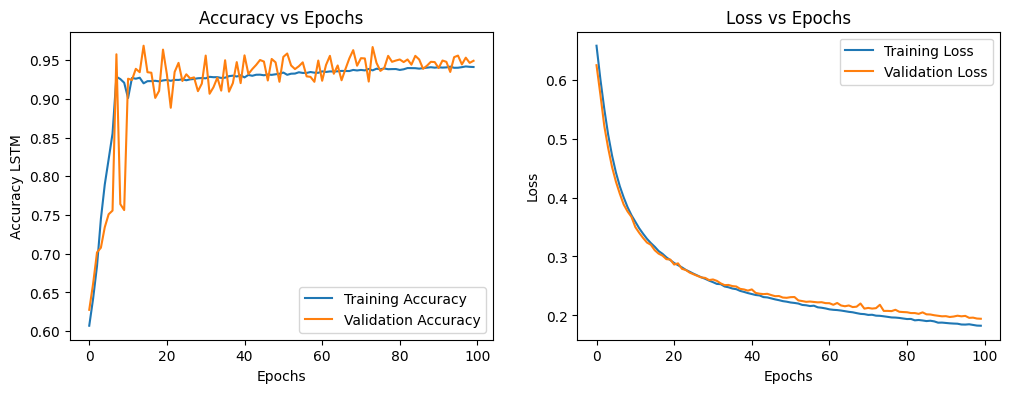

Classification Report (Training):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6060
           1       1.00      1.00      1.00      8844

    accuracy                           1.00     14904
   macro avg       1.00      1.00      1.00     14904
weighted avg       1.00      1.00      1.00     14904

Classification Report (Testing):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1548
           1       1.00      1.00      1.00      2178

    accuracy                           1.00      3726
   macro avg       1.00      1.00      1.00      3726
weighted avg       1.00      1.00      1.00      3726

The best parameter of Long Short-Term Memory (LSTM) Model is: {'activation': 'relu', 'batch_size': 64, 'epochs': 10, 'hidden_layers': 1, 'learning_rate': 10, 'lstm_units': 64}


,param_epochs,param_hidden_layers,param_learning_rate,param_lstm_units,param_activation,param_batch_size,mean_test_score,rank_test_score
0,10,1,0.01,32,relu,32,0.879831,112
1,10,1,0.01,64,relu,32,0.879026,124
2,10,1,0.1,32,relu,32,0.879428,118
3,10,1,0.1,64,relu,32,0.881106,102
4,10,1,1,32,relu,32,0.880234,107
...,...,...,...,...,...,...,...,...
123,20,2,0.1,64,tanh,64,0.916264,54
124,20,2,1,32,tanh,64,0.915593,77
125,20,2,1,64,tanh,64,0.915996,63
126,20,2,10,32,tanh,64,0.915593,77


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
# Load data
#data = pd.read_csv('tax_data.csv')

data= pd.read_csv("drive/MyDrive/Colab Notebooks/@all 2016 Dataset@.csv")
data.drop(['No','TIN','TN','TP','AST','Tpt',], axis=1, inplace=True)


# Separate features (X) and target variable (y)
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape the input data for LSTM (assuming 8 columns for input)
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])


# Reshape data for LSTM input (samples, time steps, features)
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Initialize the LSTM model
model = Sequential()

# Add LSTM layer
model.add(LSTM(units=64, input_shape=(1, 8), activation='relu'))

# Add output layer
model.add(Dense(units=1, activation='sigmoid'))  # Binary classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Define early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_split=0.2, callbacks=[early_stop])

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')

from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV

# Function to create LSTM model for KerasClassifier
def create_lstm_model(epochs=10,hidden_layers=1,learning_rate=0.1,lstm_units=32, activation='relu',batch_size=64):
    model = Sequential()
    model.add(LSTM(units=64, input_shape=(1, 8), activation='relu'))
    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Create KerasClassifier based on the create_lstm_model function
model = KerasClassifier(build_fn=create_lstm_model, verbose=0)

# Define the hyperparameter grid to search
param_grid = {
    'epochs': [10,20],
    'hidden_layers': [1,2],
    'learning_rate': [0.01,0.1,1,10],
    'lstm_units':[32,64,],
    'activation': ['relu', 'tanh'],
    'batch_size': [32, 64]
       #'dropout_rate': [0.1,0.15,0.2,0.25,0.3],

}

# Perform grid search to find the best hyperparameters
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3)
grid_result = grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_result.best_params_
print("Best Hyperparameters:", best_params)


# Plot accuracy and loss over epochs
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy LSTM')
plt.title('Accuracy vs Epochs')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

plt.show()




# Classification Report
class_report_train = classification_report(y_train, y_train)
class_report_test = classification_report(y_test, y_test)
print("Classification Report (Training):")
print(class_report_train)
print("Classification Report (Testing):")
print(class_report_test)


#display parameter
grid_search.cv_results_

# loading the results to pandas dataframe
result5 = pd.DataFrame(grid_search.cv_results_)
result5.head()

best_params = grid_search.best_estimator_
best_parameters = grid_search.best_params_


print('The best parameter of Long Short-Term Memory (LSTM) Model is:',best_parameters)
#grid_search_result5 = result5[['params','mean_test_score','rank_test_score']]
grid_search_result5 = result5[['param_epochs','param_hidden_layers','param_learning_rate','param_lstm_units','param_activation','param_batch_size','mean_test_score','rank_test_score']]
grid_search_result5

# 2nd Code for Lstm

Epoch 1/100
187/187 [==============================] - 3s 6ms/step - loss: 0.6593 - accuracy: 0.6061 - val_loss: 0.6271 - val_accuracy: 0.6250
Epoch 2/100
187/187 [==============================] - 1s 5ms/step - loss: 0.6026 - accuracy: 0.6399 - val_loss: 0.5755 - val_accuracy: 0.6605
Epoch 3/100
187/187 [==============================] - 1s 4ms/step - loss: 0.5504 - accuracy: 0.6840 - val_loss: 0.5212 - val_accuracy: 0.7011
Epoch 4/100
187/187 [==============================] - 1s 4ms/step - loss: 0.5063 - accuracy: 0.7471 - val_loss: 0.4839 - val_accuracy: 0.7078
Epoch 5/100
187/187 [==============================] - 1s 4ms/step - loss: 0.4714 - accuracy: 0.7918 - val_loss: 0.4523 - val_accuracy: 0.7340
Epoch 6/100
187/187 [==============================] - 1s 5ms/step - loss: 0.4429 - accuracy: 0.8239 - val_loss: 0.4277 - val_accuracy: 0.7504
Epoch 7/100
187/187 [==============================] - 1s 6ms/step - loss: 0.4201 - accuracy: 0.8561 - val_loss: 0.4078 - val_accuracy: 0.7538

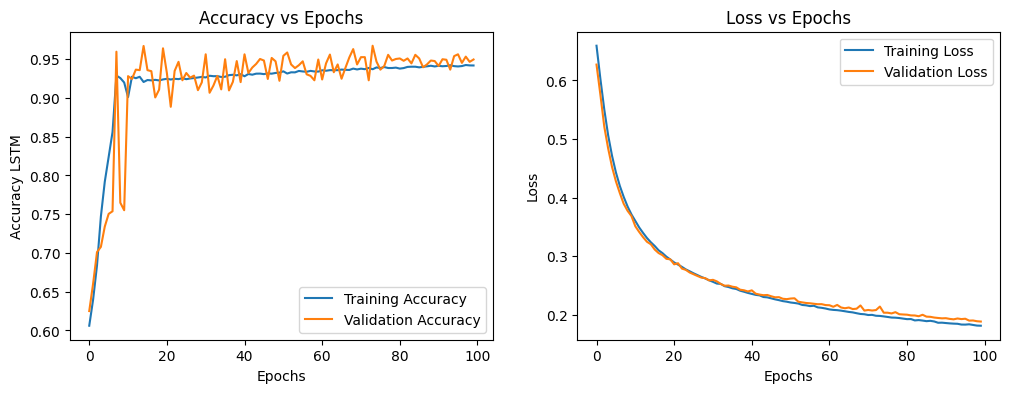

Classification Report (Training):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6060
           1       1.00      1.00      1.00      8844

    accuracy                           1.00     14904
   macro avg       1.00      1.00      1.00     14904
weighted avg       1.00      1.00      1.00     14904

Classification Report (Testing):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1548
           1       1.00      1.00      1.00      2178

    accuracy                           1.00      3726
   macro avg       1.00      1.00      1.00      3726
weighted avg       1.00      1.00      1.00      3726

The best parameter of Long Short-Term Memory (LSTM) Model is: {'activation': 'relu', 'batch_size': 64, 'epochs': 10, 'hidden_layers': 1, 'learning_rate': 0.01, 'lstm_units': 32}


,param_epochs,param_hidden_layers,param_learning_rate,param_lstm_units,param_activation,param_batch_size,mean_test_score,rank_test_score
0,10,1,0.01,32,relu,32,0.880636,91
1,10,1,0.01,64,relu,32,0.878690,134
2,10,1,0.01,128,relu,32,0.879495,121
3,10,1,0.1,32,relu,32,0.881173,81
4,10,1,0.1,64,relu,32,0.878892,130
...,...,...,...,...,...,...,...,...
427,20.1,3,1,64,tanh,128,NaN,217
428,20.1,3,1,128,tanh,128,NaN,217
429,20.1,3,10,32,tanh,128,NaN,217
430,20.1,3,10,64,tanh,128,NaN,217


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
# Load data
#data = pd.read_csv('tax_data.csv')

data= pd.read_csv("drive/MyDrive/Colab Notebooks/@all 2016 Dataset@.csv")
data.drop(['No','TIN','TN','TP','AST','Tpt',], axis=1, inplace=True)


# Separate features (X) and target variable (y)
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape the input data for LSTM (assuming 8 columns for input)
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])


# Reshape data for LSTM input (samples, time steps, features)
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Initialize the LSTM model
model = Sequential()

# Add LSTM layer
model.add(LSTM(units=64, input_shape=(1, 8), activation='relu'))

# Add output layer
model.add(Dense(units=1, activation='sigmoid'))  # Binary classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Define early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_split=0.2, callbacks=[early_stop])

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')

from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV

# Function to create LSTM model for KerasClassifier
def create_lstm_model(epochs=10,hidden_layers=1,learning_rate=0.1,lstm_units=32, activation='relu',batch_size=64):
    model = Sequential()
    model.add(LSTM(units=64, input_shape=(1, 8), activation='relu'))
    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Create KerasClassifier based on the create_lstm_model function
model = KerasClassifier(build_fn=create_lstm_model, verbose=0)

# Define the hyperparameter grid to search
param_grid = {
    'epochs': [10,20.10],
    'hidden_layers': [1,2,3],
    'learning_rate': [0.01,0.1,1,10],
    'lstm_units':[32,64,128],
    'activation': ['relu', 'tanh'],
    'batch_size': [32, 64,128]


}

# Perform grid search to find the best hyperparameters
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3)
grid_result = grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_result.best_params_
print("Best Hyperparameters:", best_params)


plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy LSTM')
plt.title('Accuracy vs Epochs')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

plt.show()

# Classification Report
class_report_train = classification_report(y_train, y_train)
class_report_test = classification_report(y_test, y_test)
print("Classification Report (Training):")
print(class_report_train)
print("Classification Report (Testing):")
print(class_report_test)


#display parameter
grid_search.cv_results_

# loading the results to pandas dataframe
result5 = pd.DataFrame(grid_search.cv_results_)
result5.head()

best_params = grid_search.best_estimator_
best_parameters = grid_search.best_params_


print('The best parameter of Long Short-Term Memory (LSTM) Model is:',best_parameters)
#grid_search_result5 = result5[['params','mean_test_score','rank_test_score']]
grid_search_result5 = result5[['param_epochs','param_hidden_layers','param_learning_rate','param_lstm_units','param_activation','param_batch_size','mean_test_score','rank_test_score']]
grid_search_result5

# 2rd Code for LSTM

In [ ]:
# Make predictions on the testing data
y_pred_prob = model.predict(X_test_lstm)

# Convert predicted probabilities to binary classes based on a threshold (e.g., 0.5)
y_pred_binary = (y_pred_prob > 0.5).astype(int)

# Evaluate the model on the testing data
accuracy = accuracy_score(y_test, y_pred_binary)
classification_report_output = classification_report(y_test, y_pred_binary)



# Print evaluation metrics
print("Accuracy:", accuracy)
print("Classification Report:")
print(classification_report_output)


117/117 [==============================] - 0s 2ms/step
Accuracy: 0.940955448201825
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      1522
           1       0.99      0.91      0.95      2204

    accuracy                           0.94      3726
   macro avg       0.94      0.95      0.94      3726
weighted avg       0.95      0.94      0.94      3726



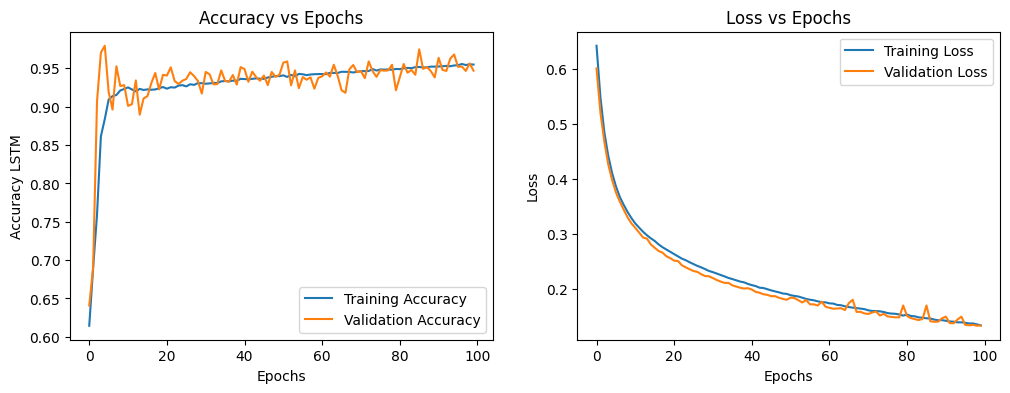

Classification Report (Training):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6086
           1       1.00      1.00      1.00      8818

    accuracy                           1.00     14904
   macro avg       1.00      1.00      1.00     14904
weighted avg       1.00      1.00      1.00     14904

Classification Report (Testing):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1522
           1       1.00      1.00      1.00      2204

    accuracy                           1.00      3726
   macro avg       1.00      1.00      1.00      3726
weighted avg       1.00      1.00      1.00      3726



AttributeError: 'GridSearchCV' object has no attribute 'cv_results_'

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import GridSearchCV

from keras.wrappers.scikit_learn import KerasClassifier
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

# Load  dataset
data= pd.read_csv("drive/MyDrive/Colab Notebooks/@all 2016 Dataset@.csv")

data.drop(['No','TIN','TN','TP','AST','Tpt',], axis=1, inplace=True)

# Preprocess the data
X = data.drop(columns=["Output"])
y = data["Output"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape the input data for LSTM
X_train_lstm = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_lstm = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

def create_lstm_model(units=64, learning_rate=0.001):
    model = Sequential()
    model.add(LSTM(units=units, input_shape=(1, X_train.shape[1]), activation='relu'))
    model.add(Dense(units=1, activation='sigmoid'))  # Use 'sigmoid' activation for binary classification
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Define early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Create KerasClassifier based on the create_lstm_model function
model = create_lstm_model()

# Train your model
history = model.fit(X_train_lstm, y_train, epochs=100, batch_size=32, verbose=0, validation_split=0.2, callbacks=[early_stop])

param_grid = {
    'units': [32, 64],
    'optimizer': ['adam', 'rmsprop'],
    'learning_rate': [0.001, 0.01, 0.1],
 #   'hidden_layers': [1, 2],
 #   'batch_size': [32, 64],
   'activation': ['relu', 'tanh'],
    'epochs': [10, 20]
}

# Make predictions on the testing data
y_pred_prob = model.predict(X_test_lstm)

# Convert predicted probabilities to binary classes based on a threshold (e.g., 0.5)
y_pred_binary = (y_pred_prob > 0.5).astype(int)

# Evaluate the model on the testing data
accuracy = accuracy_score(y_test, y_pred_binary)
classification_report_output = classification_report(y_test, y_pred_binary)



# Print evaluation metrics
print("Accuracy:", accuracy)
print("Classification Report:")
print(classification_report_output)



plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy LSTM')
plt.title('Accuracy vs Epochs')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

plt.show()



from keras.wrappers.scikit_learn import KerasClassifier
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

# Create a KerasClassifier
lstm_classifier = KerasClassifier(build_fn=create_lstm_model, verbose=1)


# Classification Report
class_report_train = classification_report(y_train, y_train)
class_report_test = classification_report(y_test, y_test)
print("Classification Report (Training):")
print(class_report_train)
print("Classification Report (Testing):")
print(class_report_test)


#display parameter
grid_search.cv_results_

# loading the results to pandas dataframe
result5 = pd.DataFrame(grid_search.cv_results_)
result5.head()

best_params = grid_search.best_estimator_
best_parameters = grid_search.best_params_



print('The best parameter of Long Short-Term Memory (LSTM) Model is:',best_parameters)
#grid_search_result5 = result5[['params','mean_test_score','rank_test_score']]
grid_search_result5 = result5[['param_optimizer','param_epochs','param_learning_rate','param_units','param_activation','mean_test_score','rank_test_score']]
grid_search_result5

